# Atividade - LSTM vs. Transformer em Classificação de Texto

## Especificação

Nesta atividade você deve treinar do zero, sem pesos pré-treinados, dois classificadores de sentimento sobre o dataset IMDB e compará-los: um LSTM e um Transformer encoder. A entrega é um único notebook `.ipynb` executado, com as saídas visíveis.

O IMDB é um conjunto clássico de classificação de sentimento composto por resenhas de filmes escritas por usuários, rotuladas como positivas ou negativas. São 25 mil exemplos de treino e 25 mil de teste, com as duas classes balanceadas em cada partição. As resenhas têm em média algo em torno de 230 palavras.

Comece preparando os dados. Carregue o IMDB com o trecho abaixo, separe uma fatia de validação a partir do treino e deixe o conjunto de teste intocado até o final.

```python
!pip install -q datasets
from datasets import load_dataset

raw = load_dataset("imdb")
train_full = raw["train"].shuffle(seed=42)
test_ds    = raw["test"]
# 2000 exemplos para validação, o restante para treino
val_texts,  val_labels  = train_full["text"][:2000], train_full["label"][:2000]
train_texts, train_labels = train_full["text"][2000:], train_full["label"][2000:]
test_texts, test_labels = test_ds["text"], test_ds["label"]
```

Em seguida, tokenize o texto e construa um vocabulário a partir do conjunto de treino apenas, pois construir no teste é vazamento. Use o mesmo tokenizador e o mesmo vocabulário para os dois modelos, que é a condição que torna a comparação honesta. Aplique padding por batch e gere a máscara correspondente, que será usada tanto pelo pooling do LSTM quanto pelo `src_key_padding_mask` do Transformer.

Implemente então as duas arquiteturas. O LSTM parte de uma camada de embedding, passa por uma rede recorrente e agrega os estados em um vetor com pooling mascarado antes da camada de classificação. O Transformer encoder parte do mesmo embedding, soma um positional encoding, passa por algumas camadas de `TransformerEncoderLayer` e agrega de forma análoga.

Treine os dois modelos sob as mesmas condições, mesmas épocas e mesmo critério de parada, e registre o tempo de treino de cada um. Ao final, avalie ambos no conjunto de teste e gere uma matriz de confusão para cada modelo. Compare os dois eixos: a qualidade da classificação, lida pelas matrizes de confusão, e o custo, lido pelos tempos de execução. Discute qual modelo se saiu melhor, a que custo, e o que isso sugere sobre o viés indutivo de cada arquitetura quando se treina do zero.

## Investigação preliminar dos dados

### Imports e configurações globais

In [1]:
from datasets import load_dataset
from collections import Counter
import html
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd
import re
import torch

In [2]:
# Seleciona o dispositivo com prioridade: CUDA > MPS > CPU
device = torch.device(
    'cuda' if torch.cuda.is_available() # GPU
    else 'mps' if torch.backends.mps.is_available() # MPS (Mac Silicon)
    else 'cpu' # CPU
)
print(f"Usando o dispositivo: {device}")

Usando o dispositivo: mps


### Configurações globais da etapa de preparação textual

In [3]:
RANDOM_STATE = 42

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

PAD_IDX = 0
UNK_IDX = 1

VOCAB_SIZE_CANDIDATES = [
    5_000,
    10_000,
    15_000,
    20_000,
    30_000,
    50_000,
    73_000,
]

LENGTH_PERCENTILES = [
    0.00,
    0.01,
    0.05,
    0.10,
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99,
    1.00,
]

### Download do dataset

In [4]:
raw_dataset = load_dataset("stanfordnlp/imdb")
train_full = raw_dataset["train"].shuffle(seed=RANDOM_STATE)
test_ds    = raw_dataset["test"]

# 2000 exemplos para validação, o restante para treino
val_texts,  val_labels  = train_full["text"][:2000], train_full["label"][:2000]
train_texts, train_labels = train_full["text"][2000:], train_full["label"][2000:]

test_texts, test_labels = test_ds["text"], test_ds["label"]

### Pré-processamento

#### Expansão de contrações comuns em inglês

In [5]:
COMMON_CONTRACTIONS = [
    # Casos específicos com "'s" interpretado como "is".
    (r"\bit's\b", "it is"),
    (r"\bthat's\b", "that is"),
    (r"\bthere's\b", "there is"),
    (r"\bwhat's\b", "what is"),
    (r"\bwho's\b", "who is"),
    (r"\bhere's\b", "here is"),
    (r"\bwhere's\b", "where is"),
    (r"\bhow's\b", "how is"),

    # Contrações irregulares.
    (r"\bwon't\b", "will not"),
    (r"\bcan't\b", "can not"),
    (r"\bain't\b", "is not"),

    # Contrações regulares.
    (r"n't\b", " not"),
    (r"'re\b", " are"),
    (r"'ve\b", " have"),
    (r"'ll\b", " will"),
    (r"'m\b", " am"),

    # Simplificação: "'d" pode significar "would" ou "had".
    (r"'d\b", " would"),

    # Possessivos remanescentes.
    (r"'s\b", ""),

    # Apóstrofos finais, como em James' ou actors'.
    (r"'\b", ""),
]


def expand_common_contractions(text):
    """
    Expande contrações comuns da língua inglesa.

    A ordem das regras é importante:
    regras específicas devem ocorrer antes das regras genéricas.
    """
    for pattern, replacement in COMMON_CONTRACTIONS:
        text = re.sub(pattern, replacement, text)
    return text

### Pré-processamento textual

Antes da tokenização, aplicamos uma etapa de normalização textual com expansão de contrações comuns da língua inglesa. Essa decisão é importante em análise de sentimentos porque contrações frequentemente expressam negação, como em `didn't`, `wasn't`, `can't` e `won't`. Se a pontuação fosse removida antes desse tratamento, parte dessa informação poderia ser degradada ou transformada em tokens menos interpretáveis.

Assim, expressões como `didn't like`, `wasn't good` e `can't recommend` são convertidas para `did not like`, `was not good` e `can not recommend`. Isso preserva explicitamente tokens associados à negação, que são relevantes para a polaridade do sentimento. Após essa expansão, caracteres especiais, hífens e barras são substituídos por espaços, evitando concatenações artificiais como `lowbudget` ou `writerdirector`.

Optamos por não preservar sinais de pontuação como tokens específicos. Embora `!` e `?` possam carregar informação de intensidade ou ênfase, a tarefa de classificação de sentimentos no IMDB tende a depender principalmente das palavras e expressões presentes no texto, especialmente termos avaliativos e estruturas de negação. Para manter o pipeline simples, reprodutível e consistente entre os dois modelos, a pontuação foi tratada como separador e substituída por espaços após a expansão das contrações.

Esse mesmo pré-processamento é aplicado a todos os conjuntos e compartilhado pelos dois modelos, garantindo que LSTM e Transformer recebam os textos normalizados segundo o mesmo critério.

In [6]:
def preprocess_text(text):
    """
    Normaliza o texto antes da tokenização.

    Etapas:
    - converte para minúsculas;
    - decodifica entidades HTML;
    - normaliza apóstrofos;
    - remove tags HTML;
    - remove URLs;
    - normaliza quebras de linha;
    - expande contrações;
    - troca caracteres especiais por espaço;
    - normaliza espaços.
    """
    if text is None:
        return ""

    text = str(text)

    # Decodifica entidades HTML, por exemplo &amp;.
    text = html.unescape(text)

    # Minúsculas.
    text = text.lower()

    # Normaliza diferentes formas de apóstrofo.
    text = re.sub(r"[‘’`´]", "'", text)

    # Remove tags HTML.
    text = re.sub(r"<[^>]+>", " ", text)

    # Remove URLs.
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # Substitui quebras de linha literais e reais por espaço.
    text = re.sub(r"\\n|\n|\r|\t", " ", text)

    # Expande contrações antes de remover pontuação.
    text = expand_common_contractions(text)

    # Substitui caracteres especiais por espaço.
    # Evita concatenação artificial:
    # low-budget -> low budget
    # writer/director -> writer director
    text = re.sub(r"[^\w\s]", " ", text)

    # Remove underscores isolados como parte de \w, se aparecerem.
    text = re.sub(r"_+", " ", text)

    # Normaliza espaços.
    text = re.sub(r"\s+", " ", text).strip()

    return text


def tokenize_text(text):
    """
    Tokeniza o texto já pré-processado usando separação por espaço.
    """
    if not text:
        return []
    return text.split()

In [7]:
# ============================================================
# Sanity check do preprocessor
# ============================================================

PREPROCESSOR_TEST_TEXTS = [
    " Hello, the world's our ! ",
    "you´ve ",
    "weren`t ",
    "could’ve ",
    "writer-director",
    "shouldn't ",
    "low-budget ",
    "would've ",
    "they'd ",
    "over-the-top ",
    "pg-13 ",
    "must-see ",
    "it'll ",
    "It's a movie that I didn't like.",
    "You've probably seen Hitchcock's films.",
    "The low-budget writer/director couldn't finish it.",
    "They'll say it wasn't Chaplin's best work.",
    "James' film isn't one of the actors' best performances.",
]

for original_text in PREPROCESSOR_TEST_TEXTS:
    print(f"[{original_text}] => [{preprocess_text(original_text)}]")

[ Hello, the world's our ! ] => [hello the world our]
[you´ve ] => [you have]
[weren`t ] => [were not]
[could’ve ] => [could have]
[writer-director] => [writer director]
[shouldn't ] => [should not]
[low-budget ] => [low budget]
[would've ] => [would have]
[they'd ] => [they would]
[over-the-top ] => [over the top]
[pg-13 ] => [pg 13]
[must-see ] => [must see]
[it'll ] => [it will]
[It's a movie that I didn't like.] => [it is a movie that i did not like]
[You've probably seen Hitchcock's films.] => [you have probably seen hitchcock films]
[The low-budget writer/director couldn't finish it.] => [the low budget writer director could not finish it]
[They'll say it wasn't Chaplin's best work.] => [they will say it was not chaplin best work]
[James' film isn't one of the actors' best performances.] => [james film is not one of the actors best performances]


### Executando pré-processamento

In [8]:
# ============================================================
# Aplicação do pré-processamento somente nos conjuntos já definidos
# pela especificação da atividade
# ============================================================

train_clean_texts = [preprocess_text(text) for text in train_texts]
val_clean_texts = [preprocess_text(text) for text in val_texts]
test_clean_texts = [preprocess_text(text) for text in test_texts]

train_tokenized_texts = [tokenize_text(text) for text in train_clean_texts]
val_tokenized_texts = [tokenize_text(text) for text in val_clean_texts]
test_tokenized_texts = [tokenize_text(text) for text in test_clean_texts]

### Verificações básicas após limpeza

In [9]:
# ============================================================
# Verificações básicas após limpeza
# ============================================================

def summarize_clean_dataset(name, clean_texts, labels):
    empty_count = sum(len(text.strip()) == 0 for text in clean_texts)
    label_counts = pd.Series(labels).value_counts().sort_index()

    print(f"=== {name} ===")
    print(f"Amostras: {len(clean_texts):,}")
    print(f"Textos vazios após limpeza: {empty_count:,}")
    print()
    print("Distribuição das classes:")
    print(label_counts)
    print()


summarize_clean_dataset("Treino", train_clean_texts, train_labels)
summarize_clean_dataset("Validação", val_clean_texts, val_labels)
summarize_clean_dataset("Teste", test_clean_texts, test_labels)

=== Treino ===
Amostras: 23,000
Textos vazios após limpeza: 0

Distribuição das classes:
0    11500
1    11500
Name: count, dtype: int64

=== Validação ===
Amostras: 2,000
Textos vazios após limpeza: 0

Distribuição das classes:
0    1000
1    1000
Name: count, dtype: int64

=== Teste ===
Amostras: 25,000
Textos vazios após limpeza: 0

Distribuição das classes:
0    12500
1    12500
Name: count, dtype: int64



### Distribuição de comprimento dos textos

Antes de definir o tamanho máximo das sequências de entrada, analisamos a distribuição do comprimento das reviews após a etapa de pré-processamento e tokenização. Essa análise é necessária porque os textos do IMDB possuem tamanhos bastante variados, incluindo reviews curtas e outras muito longas.

A escolha de `MAX_LEN` afeta diretamente dois aspectos do experimento. Por um lado, sequências muito curtas aumentam o truncamento e podem descartar partes relevantes do texto. Por outro, sequências muito longas aumentam o custo computacional, especialmente no Transformer encoder, cujo mecanismo de atenção é mais sensível ao comprimento da entrada.

Por isso, a janela de contexto não será definida pelo maior texto observado, mas sim a partir dos percentis da distribuição de comprimento no conjunto de treino. Dessa forma, buscamos um compromisso entre preservar informação suficiente das reviews e evitar que poucos textos extremos determinem o custo de todo o experimento.

In [10]:
# ============================================================
# Distribuição de comprimento dos textos
# A análise deve usar o conjunto de treino efetivo.
# ============================================================

train_lengths = pd.Series(
    [len(tokens) for tokens in train_tokenized_texts],
    name="length"
)

val_lengths = pd.Series(
    [len(tokens) for tokens in val_tokenized_texts],
    name="length"
)

test_lengths = pd.Series(
    [len(tokens) for tokens in test_tokenized_texts],
    name="length"
)

In [11]:
def br_number(value, decimals=0):
    """
    Formata um número no padrão brasileiro.
    """
    formatted = f"{value:,.{decimals}f}"
    return formatted.replace(",", "X").replace(".", ",").replace("X", ".")


def describe_numeric_variable(values, name="variável", decimals=0):
    """
    Descreve uma variável numérica com percentis e assimetria.
    """
    values = pd.Series(values)

    rows = []

    for percentile in LENGTH_PERCENTILES:
        value = values.quantile(percentile)
        accumulated = (values <= value).sum()

        rows.append({
            "percentil": f"P{int(percentile * 100):02d}",
            "valor": value,
            "qtd_acumulada": accumulated,
            "pct_acumulado": accumulated / len(values) * 100,
        })

    percentiles_df = pd.DataFrame(rows)

    summary = {
        "nome": name,
        "média": values.mean(),
        "mediana": values.median(),
        "mínimo": values.min(),
        "máximo": values.max(),
        "skewness": values.skew(),
    }

    print(f"=== Percentis de {name} ===")
    display(
        percentiles_df.style.format({
            "valor": f"{{:,.{decimals}f}}",
            "qtd_acumulada": "{:,.0f}",
            "pct_acumulado": "{:.2f}%",
        })
    )

    print(f"\n=== Assimetria de {name} ===")
    print(f"Média   : {br_number(summary['média'], decimals)}")
    print(f"Mediana : {br_number(summary['mediana'], decimals)}")
    print(f"Mínimo  : {br_number(summary['mínimo'], decimals)}")
    print(f"Máximo  : {br_number(summary['máximo'], decimals)}")
    print(f"Skewness: {br_number(summary['skewness'], 2)}")

    return percentiles_df, summary

In [12]:
length_percentiles_df, length_summary = describe_numeric_variable(
    train_lengths,
    name="tamanho das reviews de treino em tokens",
    decimals=0,
)

=== Percentis de tamanho das reviews de treino em tokens ===


,percentil,valor,qtd_acumulada,pct_acumulado
0,P00,10,1,0.00%
1,P01,43,247,1.07%
2,P05,65,"1,159",5.04%
3,P10,92,"2,318",10.08%
4,P25,129,"5,824",25.32%
5,P50,177,"11,542",50.18%
6,P75,288,"17,251",75.00%
7,P90,464,"20,704",90.02%
8,P95,606,"21,853",95.01%
9,P99,922,"22,770",99.00%



=== Assimetria de tamanho das reviews de treino em tokens ===
Média   : 237
Mediana : 177
Mínimo  : 10
Máximo  : 2.483
Skewness: 2,17


In [13]:
def format_number_br_axis(x, pos):
    """
    Formata números do eixo no padrão brasileiro.
    """
    return f"{x:,.0f}".replace(",", ".")


def plot_length_distribution(
    values,
    name="tamanho das reviews em tokens",
    limit_percentile=0.99,
    marked_percentiles=(0.25, 0.50, 0.75, 0.90, 0.95, 0.99),
    bins=50,
):
    """
    Plota histograma da distribuição de comprimento com percentis marcados.
    """
    values = pd.Series(values)

    limit = values.quantile(limit_percentile)
    filtered_values = values[values <= limit]

    plt.figure(figsize=(12, 6))
    plt.hist(
        filtered_values,
        bins=bins,
        edgecolor="black",
        alpha=0.7,
    )

    plt.gca().xaxis.set_major_formatter(FuncFormatter(format_number_br_axis))

    max_height = plt.ylim()[1]

    for percentile in marked_percentiles:
        value = values.quantile(percentile)

        if value <= limit:
            plt.axvline(
                value,
                linestyle="--",
                linewidth=1.5,
                alpha=0.8,
            )
            plt.text(
                value,
                max_height * 0.95,
                f"P{int(percentile * 100)}: {value:.0f}",
                rotation=90,
                ha="center",
                va="top",
            )

    plt.title(
        f"Distribuição de {name} até o percentil "
        f"{int(limit_percentile * 100)}"
    )
    plt.xlabel(name)
    plt.ylabel("Frequência")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

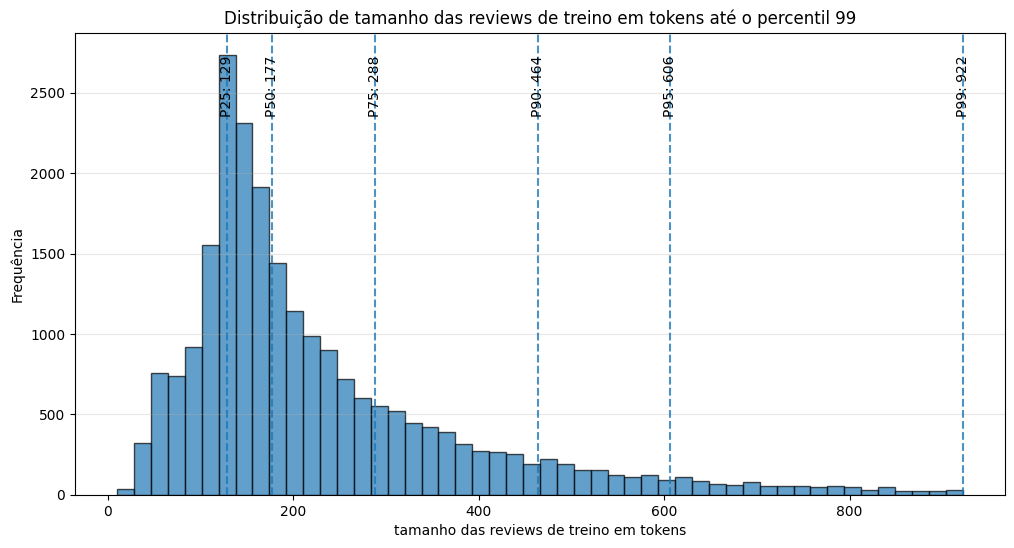

In [14]:
plot_length_distribution(
    train_lengths,
    name="tamanho das reviews de treino em tokens",
    limit_percentile=0.99,
    marked_percentiles=(0.25, 0.50, 0.75, 0.90, 0.95, 0.99),
    bins=50,
)

### Analise da Cobertura do Vocabulário

Antes de construir o vocabulário usado pelos modelos, analisamos a cobertura das ocorrências de tokens para diferentes tamanhos de vocabulário. Essa etapa é importante porque utilizar todos os tokens distintos do conjunto de treino nem sempre é a melhor escolha: palavras muito raras aumentam o tamanho da matriz de embeddings e o custo computacional, mas tendem a contribuir pouco para a capacidade de generalização do modelo.

A análise será feita exclusivamente sobre o conjunto de treino, evitando qualquer vazamento de informação dos conjuntos de validação e teste. Tokens que não forem incluídos no vocabulário serão representados pelo token especial `<UNK>`.

O objetivo é identificar um ponto de equilíbrio entre cobertura textual e complexidade do modelo. Vocabulários pequenos produzem mais tokens desconhecidos, podendo perder informação relevante. Vocabulários muito grandes reduzem a taxa de OOV, mas aumentam o número de parâmetros e podem incorporar ruído associado a termos raros, nomes próprios, erros de digitação e variações pouco frequentes.

Assim, avaliamos diferentes valores candidatos para `VOCAB_SIZE` e observamos a cobertura acumulada das ocorrências. A escolha final será feita com base no menor vocabulário capaz de atingir uma cobertura considerada adequada para o experimento.

In [15]:
# ============================================================
# Contagem de tokens somente no treino efetivo
# ============================================================

token_counts = Counter(
    token
    for tokens in train_tokenized_texts
    for token in tokens
)

ordered_frequencies = sorted(
    token_counts.values(),
    reverse=True,
)

total_token_occurrences = sum(ordered_frequencies)
total_unique_tokens = len(ordered_frequencies)

print(f"Total de ocorrências de tokens no treino: {br_number(total_token_occurrences)}")
print(f"Quantidade de tokens distintos no treino: {br_number(total_unique_tokens)}")

Total de ocorrências de tokens no treino: 5.453.423
Quantidade de tokens distintos no treino: 72.460


In [16]:
def calculate_vocabulary_coverage(
    ordered_frequencies,
    vocab_size_candidates,
    reserved_tokens_count=2,
):
    """
    Calcula cobertura de ocorrências para diferentes tamanhos de vocabulário.

    reserved_tokens_count representa tokens especiais como:
    - <PAD>
    - <UNK>

    Portanto, um VOCAB_SIZE de 15.000 comporta:
    2 tokens especiais + 14.998 tokens reais.
    """
    total_occurrences = sum(ordered_frequencies)
    total_unique = len(ordered_frequencies)

    results = []

    for vocab_size in vocab_size_candidates:
        real_token_capacity = max(vocab_size - reserved_tokens_count, 0)
        effective_real_tokens = min(real_token_capacity, total_unique)

        covered_occurrences = sum(
            ordered_frequencies[:effective_real_tokens]
        )

        oov_occurrences = total_occurrences - covered_occurrences

        results.append({
            "VOCAB_SIZE": vocab_size,
            "tokens_reais_incluidos": effective_real_tokens,
            "ocorrencias_cobertas": covered_occurrences,
            "cobertura_%": covered_occurrences / total_occurrences * 100,
            "ocorrencias_oov": oov_occurrences,
            "oov_%": oov_occurrences / total_occurrences * 100,
        })

    return pd.DataFrame(results)

In [17]:
vocabulary_coverage_df = calculate_vocabulary_coverage(
    ordered_frequencies=ordered_frequencies,
    vocab_size_candidates=VOCAB_SIZE_CANDIDATES,
    reserved_tokens_count=2,
)

display(
    vocabulary_coverage_df.style.format({
        "VOCAB_SIZE": "{:,.0f}",
        "tokens_reais_incluidos": "{:,.0f}",
        "ocorrencias_cobertas": "{:,.0f}",
        "cobertura_%": "{:.2f}%",
        "ocorrencias_oov": "{:,.0f}",
        "oov_%": "{:.2f}%",
    })
)

,VOCAB_SIZE,tokens_reais_incluidos,ocorrencias_cobertas,cobertura_%,ocorrencias_oov,oov_%
0,"5,000","4,998","4,935,683",90.51%,"517,740",9.49%
1,"10,000","9,998","5,167,462",94.76%,"285,961",5.24%
2,"15,000","14,998","5,270,185",96.64%,"183,238",3.36%
3,"20,000","19,998","5,327,900",97.70%,"125,523",2.30%
4,"30,000","29,998","5,387,126",98.78%,"66,297",1.22%
5,"50,000","49,998","5,430,961",99.59%,"22,462",0.41%
6,"73,000","72,460","5,453,423",100.00%,0,0.00%


In [18]:
def plot_vocabulary_coverage(vocabulary_coverage_df):
    """
    Plota cobertura acumulada por tamanho de vocabulário.
    """
    plt.figure(figsize=(10, 5))

    plt.plot(
        vocabulary_coverage_df["VOCAB_SIZE"],
        vocabulary_coverage_df["cobertura_%"],
        marker="o",
    )

    for vocab_size, coverage in zip(
        vocabulary_coverage_df["VOCAB_SIZE"],
        vocabulary_coverage_df["cobertura_%"],
    ):
        plt.annotate(
            f"{coverage:.1f}%",
            xy=(vocab_size, coverage),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
            fontsize=9,
        )

    plt.title("Cobertura do vocabulário por quantidade de tokens")
    plt.xlabel("Tamanho do vocabulário")
    plt.ylabel("Cobertura das ocorrências (%)")
    plt.grid(True, alpha=0.3)
    plt.show()

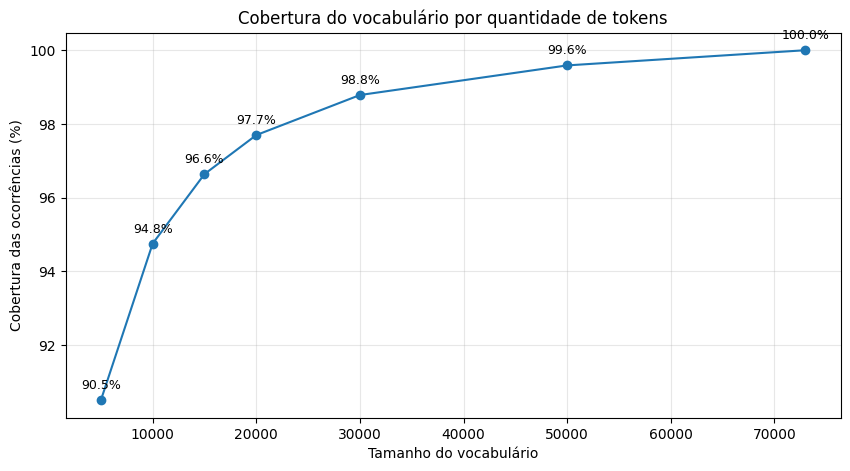

In [19]:
plot_vocabulary_coverage(vocabulary_coverage_df)

### Escolhendo os parâmetros básicos

#### Janela de Contexto

A distribuição do tamanho das reviews apresenta forte assimetria à direita, com mediana de 177 tokens, média de 237 tokens e máximo de 2.483 tokens. Essa diferença indica a presença de uma cauda longa composta por reviews muito maiores que a maioria do conjunto.

Como o custo computacional cresce com o tamanho da sequência, especialmente no Transformer encoder devido ao mecanismo de atenção, não é adequado definir a janela de contexto com base no maior texto observado. Por outro lado, escolher uma janela muito curta aumentaria excessivamente o truncamento das reviews.

Assim, adotamos o percentil 90 como referência para a janela de contexto, resultando em MAX_LEN = 464. Esse valor preserva integralmente aproximadamente 90% das reviews do conjunto de treino e limita o impacto dos textos extremos, estabelecendo um compromisso entre retenção de informação e custo computacional. O mesmo MAX_LEN será utilizado tanto no modelo LSTM quanto no Transformer, garantindo uma comparação justa entre as arquiteturas.

In [20]:
SELECTED_MAX_LEN_PERCENTILE = 0.90

SELECTED_MAX_LEN = int(
    train_lengths.quantile(SELECTED_MAX_LEN_PERCENTILE)
)

print(
    f"SELECTED_MAX_LEN definido pelo P{int(SELECTED_MAX_LEN_PERCENTILE * 100)}: "
    f"{SELECTED_MAX_LEN}"
)

SELECTED_MAX_LEN definido pelo P90: 464


#### Tamanho do Vocabulário

A análise de cobertura mostra que o vocabulário de 5.000 tokens cobre 90,51% das ocorrências do conjunto de treino, enquanto 10.000 tokens cobrem 94,76%. A partir de 15.000 tokens, a cobertura chega a 96,64%, reduzindo a taxa estimada de OOV para 3,36%.

Como o ganho marginal diminui progressivamente após esse ponto, adotamos VOCAB_SIZE = 15.000. Essa escolha mantém uma cobertura elevada do corpus sem aumentar excessivamente a quantidade de parâmetros da camada de embeddings, que será compartilhada pelos modelos LSTM e Transformer.

In [21]:
SELECTED_VOCAB_COVERAGE_THRESHOLD = 0.95

selected_vocab_row = vocabulary_coverage_df[
    vocabulary_coverage_df["cobertura_%"] >= SELECTED_VOCAB_COVERAGE_THRESHOLD * 100
].iloc[0]

SELECTED_VOCAB_SIZE = int(
    selected_vocab_row["VOCAB_SIZE"]
)

print(
    f"SELECTED_VOCAB_SIZE definido pela cobertura mínima "
    f"de {SELECTED_VOCAB_COVERAGE_THRESHOLD:.0%}: "
    f"{SELECTED_VOCAB_SIZE:,}"
)

SELECTED_VOCAB_SIZE definido pela cobertura mínima de 95%: 15,000


#### Tamanho de Embedding

Como os dois modelos serão treinados do zero e comparados sob as mesmas condições, a dimensão dos embeddings foi definida como um valor fixo e compartilhado entre as arquiteturas. Essa escolha evita que diferenças de desempenho sejam atribuídas a representações de entrada distintas, preservando a comparação entre o LSTM e o Transformer encoder.

Adotamos `EMBED_DIM = 128` por representar um compromisso adequado entre capacidade representacional e custo computacional. Esse valor oferece uma representação suficientemente expressiva para os tokens do vocabulário, sem aumentar excessivamente o número de parâmetros da camada de embeddings. Com `VOCAB_SIZE = 15.000`, a matriz de embeddings terá aproximadamente 1,92 milhão de parâmetros, um tamanho adequado para o experimento.

Além disso, `128` é conveniente para o Transformer encoder porque oferece divisões regulares para diferentes quantidades de cabeças de atenção. Por exemplo, podemos usar 2 cabeças com 64 dimensões cada, 4 cabeças com 32 dimensões cada ou 8 cabeças com 16 dimensões cada. Isso mantém a dimensão interna do modelo compatível com o mecanismo de multi-head attention e permite ajustar a quantidade de cabeças sem alterar a dimensão dos embeddings. Assim, o mesmo valor atende bem às duas arquiteturas: fornece vetores de entrada suficientemente ricos para o LSTM e define uma dimensão interna moderada e flexível para o Transformer.

In [22]:
# ============================================================
# Decisões compartilhadas pelos dois modelos
# ============================================================
SELECTED_EMBED_DIM = 128

## Desenvolvendo o modelo

### Montando traduções: vocabulário <-> índice

In [23]:
most_common_tokens = [
    token
    for token, _ in token_counts.most_common(SELECTED_VOCAB_SIZE - 2)
]

idx_to_str = [PAD_TOKEN, UNK_TOKEN] + most_common_tokens
str_to_idx = {
    token: idx
    for idx, token in enumerate(idx_to_str)
}

VOCAB_SIZE = len(idx_to_str)
MAX_LEN = SELECTED_MAX_LEN
EMBED_DIM = SELECTED_EMBED_DIM

print(f"VOCAB_SIZE efetivo: {VOCAB_SIZE:,}")
print(f"MAX_LEN escolhido : {MAX_LEN:,}")
print(f"EMBED_DIM escolhido: {EMBED_DIM:,}")
print(f"PAD_IDX: {PAD_IDX}")
print(f"UNK_IDX: {UNK_IDX}")

VOCAB_SIZE efetivo: 15,000
MAX_LEN escolhido : 464
EMBED_DIM escolhido: 128
PAD_IDX: 0
UNK_IDX: 1


### Verificando taxa de ocorrência de tokens <UNK>

In [24]:
def encode_tokens(tokens, str_to_idx, max_len):
    """
    Converte lista de tokens em ids, aplica truncamento à direita
    e mantém tokens desconhecidos como UNK_IDX.

    O padding não é feito aqui. Ele será feito por batch no DataLoader.
    """
    token_ids = [
        str_to_idx.get(token, UNK_IDX)
        for token in tokens[:max_len]
    ]

    return token_ids


def calculate_unk_rate(tokenized_texts, str_to_idx, max_len=None):
    """
    Calcula proporção de tokens que seriam mapeados para <UNK>.
    """
    total_tokens = 0
    unk_tokens = 0

    for tokens in tokenized_texts:
        if max_len is not None:
            tokens = tokens[:max_len]

        total_tokens += len(tokens)
        unk_tokens += sum(
            1
            for token in tokens
            if token not in str_to_idx
        )

    if total_tokens == 0:
        return 0.0

    return unk_tokens / total_tokens

In [25]:
train_unk_rate = calculate_unk_rate(
    train_tokenized_texts,
    str_to_idx,
    max_len=MAX_LEN,
)

val_unk_rate = calculate_unk_rate(
    val_tokenized_texts,
    str_to_idx,
    max_len=MAX_LEN,
)

test_unk_rate = calculate_unk_rate(
    test_tokenized_texts,
    str_to_idx,
    max_len=MAX_LEN,
)

unk_summary_df = pd.DataFrame([
    {
        "conjunto": "treino",
        "unk_%": train_unk_rate * 100,
    },
    {
        "conjunto": "validação",
        "unk_%": val_unk_rate * 100,
    },
    {
        "conjunto": "teste",
        "unk_%": test_unk_rate * 100,
    },
])

display(
    unk_summary_df.style.format({
        "unk_%": "{:.2f}%"
    })
)

,conjunto,unk_%
0,treino,3.32%
1,validação,3.48%
2,teste,3.95%


### Codificando os datasets com o vocabulário

In [26]:
# ============================================================
# Versões codificadas, ainda sem padding global.
# O padding será por batch no DataLoader.
# ============================================================

train_encoded_texts = [
    encode_tokens(tokens, str_to_idx, MAX_LEN)
    for tokens in train_tokenized_texts
]

val_encoded_texts = [
    encode_tokens(tokens, str_to_idx, MAX_LEN)
    for tokens in val_tokenized_texts
]

test_encoded_texts = [
    encode_tokens(tokens, str_to_idx, MAX_LEN)
    for tokens in test_tokenized_texts
]

print("Exemplo codificado:")
print(train_encoded_texts[0][:50])

Exemplo codificado:
[11, 20, 911, 965, 2984, 15, 4, 1070, 1900, 6768, 9, 1741, 34, 3850, 4, 4669, 619, 3398, 36, 5319, 1, 4900, 5441, 9, 2, 4669, 3, 205, 52, 75, 25, 14593, 16, 54, 838, 53, 6, 13, 47, 53, 716, 7, 27, 2, 63, 6, 996, 1, 3, 2984]
